<a href="https://colab.research.google.com/" target="_parent"></a>

# Wanting What Is Needed
## Homeostasis, Allostasis and Degeneracy in Evolved Markov Brains

Companion notebook for the SAB 2026 workshop *Wanting What is Needed: From
Homeostatic Control to Adaptive Behavior* and the Biological Cybernetics paper.

**Runs on a free Colab CPU runtime with no installation** -- only `numpy`,
`pandas`, `scipy`, `matplotlib` and `networkx` are used, all pre-installed.
The actual-causation machinery is implemented from scratch (validated against
the canonical values of Albantakis et al., 2019), so **PyPhi is not required**.

| section | content |
|---|---|
| 1 | formal framework: drive, motivational salience, allostatic setpoint |
| 2 | Markov brains: genome, logic gates, TPM, connectome |
| 3 | the `HomeoTrack` environment (2x2 design) |
| 4 | artificial evolution on pure viability |
| 5 | behavioural degeneracy + perturbation tests |
| 6 | structural degeneracy |
| 7 | interoceptive autonomy $A_k^S$ |
| 8 | actual causation: causal profiles, MMI, computational degeneracy |
| 9 | analysis sweep |
| 10 | run the experiment |
| 11 | results and paper figures |

Estimated runtime with the defaults below: **~8 minutes**. Set
`CFG.full_run = True` (Sec. 10) to reproduce the settings reported in the paper.


In [1]:
# ============================================================================
# 0. SETUP
# ============================================================================
from __future__ import annotations

import itertools
import json
import math
import os
import time
from dataclasses import dataclass, field, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import entropy as sp_entropy

try:
    import networkx as nx
    HAS_NX = True
except Exception:  # pragma: no cover
    HAS_NX = False

mpl.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 8,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

OUTDIR = Path("outputs")
OUTDIR.mkdir(exist_ok=True, parents=True)

RNG = np.random.default_rng(0)

# Condition palette used throughout (H = homeostatic, A = allostatic;
# I = interoceptive sensors available, N = no interoception).
CONDITIONS = ["H-I", "H-N", "A-I", "A-N"]
CCOLOR = {"H-I": "#3C78D8", "H-N": "#6FA8DC", "A-I": "#CC0000", "A-N": "#E06666"}

---
## 1. Formal framework

### 1.1 Physiological state, viability and drive

An agent carries $d$ **essential variables** $x(t)=(x_1,\dots,x_d)\in[0,1]^d$
(here $d=2$: an energy-like and a water-like resource). They deplete
autonomously and are replenished only by acting on the world. The agent is
*viable* while $x(t)\in\mathcal V=(0,1]^d$; hitting $x_i\le 0$ terminates the life.

Following Ashby's ultrastability and the homeostatic-RL formulation of
Keramati & Gutkin, we define a **drive** as the (weighted) distance of the
physiological state from a setpoint $x^\*$,

$$ D\big(x(t)\big)=\sum_{i=1}^{d} w_i\,\big|x_i(t)-x_i^{*}\big|^{\,n},\qquad n=2 .$$

### 1.2 Motivation without reward

The **motivational salience** ("wanting") of an outcome $o$ that would change the
internal state by $\Delta_o$ is the drive reduction it affords,

$$ m(o\mid x)\;=\;D(x)-D(x\oplus\Delta_o), $$

which is a function of the *need*, not of the outcome alone: the same ingestive
act is appetitive when $x_i<x_i^{*}$ and aversive when $x_i>x_i^{*}$.
No external reward signal is given to the agent or to the evolutionary algorithm;
selection acts only on cumulative viability

$$ f=\frac{1}{T}\sum_{t=1}^{T}\mathbb 1[\text{alive at }t]\;
     \Big(1-\tfrac{D(x(t))}{D_{\max}}\Big). $$

### 1.3 Allostasis as an anticipatory setpoint

Pure homeostasis is *reactive*: it corrects a deviation that has already
occurred. **Allostasis** is regulation of the *expected future* deviation. Given a
predictive context $c(t)$ (an exteroceptive cue), define the anticipatory drive
over a horizon $H$,

$$ D_{\mathrm A}\big(x(t),c(t)\big)=\mathbb E\Big[\textstyle\sum_{k=1}^{H}\gamma^{k}\,
  D\big(x(t+k)\big)\;\Big|\;x(t),c(t),\pi\Big], $$

whose minimiser defines a **context-dependent, shifted setpoint**

$$ x^{*}_{\mathrm A}(c)\;=\;\arg\min_{x} D_{\mathrm A}(x,c)\;=\;x^{*}+\Delta(c). $$

In our environment the cue announces that one resource will become
*unavailable* for $W$ steps. The optimal response is to over-fill that reservoir
**while the current drive is still low**, i.e. to accept a present homeostatic
cost to avoid a larger future one. Behaviourally this is exactly "wanting what is
needed before it is needed".

### 1.4 What has to be measured

A viable trajectory can be produced (i) by *interoceptive control*, where the
causal influence of sensors on action is gated by the current need, or (ii) by an
*open-loop rhythm* that happens to keep $x$ inside $\mathcal V$. These are
behaviourally indistinguishable but mechanistically distinct. Section 8
introduces a causal measure, the **Motivational Modulation Index**, that
separates them, and quantifies **computational degeneracy** as the average
distance between agents' causal profiles.

---
## 2. Markov brains

Agents are **Markov brains** (Hintze et al., 2017): networks of heterogeneous,
genetically encoded deterministic logic gates whose wiring *and* node functions
are both under evolutionary control. A byte genome is translated into gates
delimited by a start codon; gates read from the sensors and hidden units and
write to the hidden units and motors, so motors cannot feed back. The whole
network is summarised by a deterministic transition probability matrix (TPM),
which is what every later analysis operates on.

In [2]:
# ============================================================================
# 2. MARKOV BRAINS
# ============================================================================
# Node layout (fixed for the whole notebook):
#   hidden  H : indices 0..3
#   sensors S : indices 4..8
#   motors  M : indices 9,10
# Sensors are set by the environment; motors cannot feed back into the network.
# The "cause set" C = H u S (9 nodes) determines the next state of the
# "effect set" E = H u M (6 nodes).

N_HIDDEN, N_SENSORS, N_MOTORS = 4, 5, 2
HIDDEN_IXS = list(range(N_HIDDEN))                                   # 0..3
SENSOR_IXS = list(range(N_HIDDEN, N_HIDDEN + N_SENSORS))             # 4..8
MOTOR_IXS = list(range(N_HIDDEN + N_SENSORS,
                       N_HIDDEN + N_SENSORS + N_MOTORS))             # 9,10
N_NODES = N_HIDDEN + N_SENSORS + N_MOTORS                            # 11

CAUSE_IXS = HIDDEN_IXS + SENSOR_IXS        # inputs to the network  (9 nodes)
EFFECT_IXS = HIDDEN_IXS + MOTOR_IXS        # outputs of the network (6 nodes)
N_CAUSE, N_EFFECT = len(CAUSE_IXS), len(EFFECT_IXS)
N_CSTATES = 2 ** N_CAUSE                   # 512
N_MSTATES = 2 ** N_MOTORS                  # 4

SENSOR_NAMES = ["S1:patchA", "S2:patchB", "S3:need1", "S4:need2", "S5:cue"]
NODE_LABELS = (["A", "B", "C", "D"] + ["S1", "S2", "S3", "S4", "S5"] + ["M1", "M2"])

# little-endian ("loli") state <-> integer conversion, as in the `autonomy` toolbox
_POW_CAUSE = (2 ** np.arange(N_CAUSE)).astype(np.int64)
ALL_CAUSE_STATES = ((np.arange(N_CSTATES)[:, None] >> np.arange(N_CAUSE)) & 1).astype(np.uint8)

START_CODON = (42, 213)
MAX_GATE_IN, MAX_GATE_OUT = 4, 2


@dataclass
class Gate:
    """A deterministic logic gate with 1-4 inputs and 1-2 outputs."""
    in_idx: np.ndarray     # positions within CAUSE_IXS
    out_idx: np.ndarray    # positions within EFFECT_IXS
    table: np.ndarray      # (2**n_in, n_out) uint8


def parse_genome(genome: np.ndarray) -> list[Gate]:
    """Translate a byte genome into a list of deterministic logic gates.

    Genes begin with the start codon (42, 213) and encode, in order:
    number of inputs, number of outputs, input addresses, output addresses and
    a truth table.  This follows the MABE / Markov-brain convention
    (Hintze et al., 2017) with deterministic gates only.
    """
    g = genome
    n = len(g)
    if n < 32:
        return []
    starts = np.flatnonzero((g[:-1] == START_CODON[0]) & (g[1:] == START_CODON[1]))
    gates: list[Gate] = []
    for i in starts[:64]:                       # cap: keeps translation bounded
        j = int(i) + 2
        n_in = 1 + int(g[j % n]) % MAX_GATE_IN
        n_out = 1 + int(g[(j + 1) % n]) % MAX_GATE_OUT
        j += 2
        idx = (j + np.arange(MAX_GATE_IN)) % n
        in_idx = (g[idx][:n_in].astype(np.int64)) % N_CAUSE
        j += MAX_GATE_IN
        idx = (j + np.arange(MAX_GATE_OUT)) % n
        out_idx = (g[idx][:n_out].astype(np.int64)) % N_EFFECT
        j += MAX_GATE_OUT
        n_rows = 2 ** n_in
        raw = g[(j + np.arange(n_rows)) % n].astype(np.int64)
        table = ((raw[:, None] >> np.arange(n_out)) & 1).astype(np.uint8)
        gates.append(Gate(in_idx, out_idx, table))
    return gates


def build_tpm(gates: list[Gate]) -> np.ndarray:
    """Deterministic state-by-node TPM: (2**N_CAUSE, N_EFFECT) uint8.

    Row k gives the next state of H u M given cause state k of H u S.
    Outputs of several gates writing to the same node are combined by OR
    (the standard Markov-brain convention).
    """
    tpm = np.zeros((N_CSTATES, N_EFFECT), dtype=np.uint8)
    for gt in gates:
        vals = ALL_CAUSE_STATES[:, gt.in_idx]                       # (512, n_in)
        rows = vals @ (2 ** np.arange(gt.in_idx.size)).astype(np.uint8)
        tpm[:, gt.out_idx] |= gt.table[rows]
    return tpm


def build_cm(gates: list[Gate]) -> np.ndarray:
    """Full (N_NODES x N_NODES) connectivity matrix implied by the gates."""
    cm = np.zeros((N_NODES, N_NODES), dtype=np.uint8)
    for gt in gates:
        for a in gt.in_idx:
            for b in gt.out_idx:
                cm[CAUSE_IXS[a], EFFECT_IXS[b]] = 1
    return cm


def effective_cm(tpm: np.ndarray) -> np.ndarray:
    """Connectivity inferred from the TPM (a gate input that never changes an
    output is not a functional connection).  Mirrors `pyphi.tpm.infer_cm`."""
    cm = np.zeros((N_NODES, N_NODES), dtype=np.uint8)
    for a in range(N_CAUSE):
        flipped = np.arange(N_CSTATES) ^ (1 << a)
        diff = (tpm != tpm[flipped]).any(axis=0)
        for b in np.where(diff)[0]:
            cm[CAUSE_IXS[a], EFFECT_IXS[b]] = 1
    return cm


# ---------------------------------------------------------------- genetics ---
def random_genome(size: int, rng: np.random.Generator) -> np.ndarray:
    g = rng.integers(0, 256, size=size, dtype=np.uint8)
    # seed a few start codons so that generation 0 is not empty
    for _ in range(4):
        p = rng.integers(0, size - 2)
        g[p], g[p + 1] = START_CODON
    return g


def mutate(genome: np.ndarray, rng: np.random.Generator,
           p_point=0.005, p_dup=0.02, p_del=0.02,
           gmin=1000, gmax=8000) -> np.ndarray:
    g = genome.copy()
    mask = rng.random(g.size) < p_point
    g[mask] = rng.integers(0, 256, size=int(mask.sum()), dtype=np.uint8)
    if rng.random() < p_dup and g.size < gmax:
        L = int(rng.integers(64, 513))
        s = int(rng.integers(0, max(1, g.size - L)))
        ins = int(rng.integers(0, g.size))
        g = np.concatenate([g[:ins], g[s:s + L], g[ins:]])
    if rng.random() < p_del and g.size > gmin:
        L = int(rng.integers(64, 513))
        s = int(rng.integers(0, max(1, g.size - L)))
        g = np.concatenate([g[:s], g[s + L:]])
    return g[:gmax]

---
## 3. The `HomeoTrack` environment

A circular track of $L=24$ cells carries two spatially separated resource
patches, **A** (cells 0-2) and **B** (cells 12-14). Each patch replenishes one
essential variable. Both variables deplete at a constant rate, so viability
requires *alternating* between the two patches; because the drive is quadratic
around $x^{*}=0.75$, both under- and over-consumption are costly, and the agent
must leave a patch once sated. This is the minimal setting in which "how much do
I want this" is not a property of the world but of the body.

**Actions** are encoded by the two motors: `00` stay, `10` move left,
`01` move right, `11` ingest (effective only on an open patch).

**Sensors** (5 bits):

| | meaning | present in |
|---|---|---|
| S1 | patch A here *and open* | all |
| S2 | patch B here | all |
| S3 | interoceptive deficit $x_1<\theta$ | I conditions |
| S4 | interoceptive deficit $x_2<\theta$ | I conditions |
| S5 | allostatic cue | A conditions |

**Conditions (2x2).** *Interoception*: `I` = S3/S4 wired to the body, `N` = both
clamped to 0, so the agent has no access to its own needs and must regulate
open-loop. *Regulation demand*: `H` = stationary world, reactive homeostasis is
sufficient; `A` = patch A closes for $W$ steps ("winter"), announced by cue S5
during the $C$ steps before closure. Surviving winter near the setpoint requires
an anticipatory upward shift of the target level of $x_1$, i.e. allostasis.

In [3]:
# ============================================================================
# 3. ENVIRONMENT
# ============================================================================
@dataclass
class EnvConfig:
    L: int = 24                      # track length (circular)
    patchA: tuple = (0, 1, 2)
    patchB: tuple = (12, 13, 14)
    x0: float = 0.75                 # initial physiological state
    setpoint: float = 0.75
    depletion: float = 0.012         # per step, per essential variable
    gain: float = 0.075              # ingestion gain per step
    theta: float = 0.70              # interoceptive threshold
    n_exp: int = 2                   # exponent of the drive function
    T: int = 180                     # steps per trial
    n_trials: int = 3
    winter_len: int = 26             # steps patch A is closed (A conditions)
    cue_len: int = 10                # cue precedes closure by this many steps
    winter_onsets: tuple = (60, 105, 75)   # per-trial onset (deterministic)
    start_positions: tuple = (6, 18, 1)


ENV = EnvConfig()
D_MAX = 2.0 * max(ENV.setpoint, 1.0 - ENV.setpoint) ** ENV.n_exp


def condition_flags(cond: str) -> tuple[bool, bool]:
    """(interoception available, allostatic demand present)"""
    return ("I" in cond.split("-")[1], cond.split("-")[0] == "A")


class HomeoTrack:
    """Vectorised HomeoTrack world: `n` independent agents/trials in lock-step."""

    def __init__(self, cfg: EnvConfig, cond: str, n: int, trial: int):
        self.cfg, self.cond, self.n = cfg, cond, n
        self.intero, self.allo = condition_flags(cond)
        self.pos = np.full(n, cfg.start_positions[trial % len(cfg.start_positions)],
                           dtype=np.int64)
        self.x = np.full((n, 2), cfg.x0, dtype=np.float64)
        self.alive = np.ones(n, dtype=bool)
        self.h = np.zeros((n, N_HIDDEN), dtype=np.uint8)
        self.m = np.zeros((n, N_MOTORS), dtype=np.uint8)
        self.t = 0
        self.w0 = cfg.winter_onsets[trial % len(cfg.winter_onsets)] if self.allo else 10 ** 9
        self.maskA = np.zeros(cfg.L, dtype=bool); self.maskA[list(cfg.patchA)] = True
        self.maskB = np.zeros(cfg.L, dtype=bool); self.maskB[list(cfg.patchB)] = True
        self.viability = np.zeros(n)
        self.dep_mult = np.ones(2)          # metabolic challenge multiplier

    # -- world state -------------------------------------------------------
    def is_winter(self, t=None) -> bool:
        t = self.t if t is None else t
        return self.w0 <= t < self.w0 + self.cfg.winter_len

    def is_cue(self, t=None) -> bool:
        t = self.t if t is None else t
        return self.w0 - self.cfg.cue_len <= t < self.w0

    def sensors(self) -> np.ndarray:
        c = self.cfg
        s = np.zeros((self.n, N_SENSORS), dtype=np.uint8)
        s[:, 0] = self.maskA[self.pos] & (not self.is_winter())     # patch A open here
        s[:, 1] = self.maskB[self.pos]
        if self.intero:
            s[:, 2] = self.x[:, 0] < c.theta
            s[:, 3] = self.x[:, 1] < c.theta
        if self.allo:
            s[:, 4] = self.is_cue()
        s *= self.alive[:, None]
        return s

    def drive(self) -> np.ndarray:
        return np.sum(np.abs(self.x - self.cfg.setpoint) ** self.cfg.n_exp, axis=1)

    # -- transition --------------------------------------------------------
    def step(self, motors: np.ndarray) -> None:
        """Apply the motor state, then run the physiology for one step."""
        c = self.cfg
        m0, m1 = motors[:, 0].astype(bool), motors[:, 1].astype(bool)
        move_l = m0 & ~m1
        move_r = ~m0 & m1
        ingest = m0 & m1
        d = np.where(move_r, 1, 0) - np.where(move_l, 1, 0)
        self.pos = (self.pos + d * self.alive) % c.L

        onA = self.maskA[self.pos] & (not self.is_winter())
        onB = self.maskB[self.pos]
        gain = np.zeros_like(self.x)
        gain[:, 0] = np.where(ingest & onA & self.alive, c.gain, 0.0)
        gain[:, 1] = np.where(ingest & onB & self.alive, c.gain, 0.0)

        self.x = self.x - (c.depletion * self.dep_mult) * self.alive[:, None] + gain
        self.x = np.minimum(self.x, 1.0)
        self.alive &= (self.x > 0).all(axis=1)
        self.x = np.maximum(self.x, 0.0)

        self.viability += self.alive * np.clip(1.0 - self.drive() / D_MAX, 0.0, 1.0)
        self.t += 1
        self.m = motors


def _cause_index(h: np.ndarray, s: np.ndarray) -> np.ndarray:
    """(n, N_HIDDEN) hidden and (n, N_SENSORS) sensor states -> TPM row index."""
    hs = np.concatenate([h, s], axis=1).astype(np.int64)
    return hs @ _POW_CAUSE


def simulate(tpms: np.ndarray, cond: str, cfg: EnvConfig = ENV,
             record: bool = False) -> tuple[np.ndarray, list]:
    """Run `tpms.shape[0]` agents through all trials.

    Returns per-agent fitness in [0, 1] and, optionally, an activity log
    (one pandas-ready dict per agent) in the format used by the `autonomy`
    toolbox: `input` (sensors at t), `hiddenBefore`, `hiddenAfter`,
    `output` (motors at t+1), plus the physiological variables.
    """
    n_agents = tpms.shape[0]
    fitness = np.zeros(n_agents)
    logs = [[] for _ in range(n_agents)] if record else None

    for trial in range(cfg.n_trials):
        w = HomeoTrack(cfg, cond, n_agents, trial)
        for t in range(cfg.T):
            s = w.sensors()
            h_before = w.h.copy()
            idx = _cause_index(h_before, s)
            nxt = tpms[np.arange(n_agents), idx]          # (n, N_EFFECT)
            h_after, motors = nxt[:, :N_HIDDEN], nxt[:, N_HIDDEN:]
            if record:
                dr = w.drive()
                for a in range(n_agents):
                    logs[a].append(dict(
                        life=trial, t=t,
                        input=list(map(int, s[a])),
                        hiddenBefore=list(map(int, h_before[a])),
                        hiddenAfter=list(map(int, h_after[a])),
                        output=list(map(int, motors[a])),
                        pos=int(w.pos[a]), x1=float(w.x[a, 0]), x2=float(w.x[a, 1]),
                        drive=float(dr[a]), alive=bool(w.alive[a]),
                        winter=bool(w.is_winter()), cue=bool(w.is_cue()),
                    ))
            w.h = h_after
            w.step(motors)
        fitness += w.viability / cfg.T
    fitness /= cfg.n_trials
    if record:
        return fitness, [pd.DataFrame(l) for l in logs]
    return fitness, None

---
## 4. Artificial evolution

A population of 80 genomes is evolved for 800 generations with tournament
selection (size 3) and one elite. Fitness is the viability functional of
Sec. 1.2 -- no behavioural shaping, no external reward. Fifty independent
evolutions are run per condition in the full setting; the default is 12.

In [4]:
# ============================================================================
# 4. EVOLUTION
# ============================================================================
@dataclass
class RunConfig:
    pop: int = 80
    generations: int = 800
    genome_size: int = 3000
    tournament: int = 3
    elite: int = 1
    n_runs: int = 12          # independent evolutions per condition
    full_run: bool = False    # True -> settings reported in the paper

    def apply_full(self):
        if self.full_run:
            self.pop, self.generations, self.n_runs = 100, 1500, 30
        return self


CFG = RunConfig().apply_full()


def evolve(cond: str, seed: int, cfg: RunConfig = CFG, env: EnvConfig = ENV,
           log_every: int = 100, verbose: bool = False) -> dict:
    rng = np.random.default_rng(seed)
    pop = [random_genome(cfg.genome_size, rng) for _ in range(cfg.pop)]
    tpms = np.zeros((cfg.pop, N_CSTATES, N_EFFECT), dtype=np.uint8)
    history = []
    best = dict(fitness=-1.0)

    for gen in range(cfg.generations):
        for i, g in enumerate(pop):
            tpms[i] = build_tpm(parse_genome(g))
        fit, _ = simulate(tpms, cond, env)
        b = int(np.argmax(fit))
        history.append((gen, float(fit[b]), float(fit.mean())))
        if fit[b] > best["fitness"]:
            best = dict(fitness=float(fit[b]), genome=pop[b].copy(), gen=gen)
        if verbose and gen % log_every == 0:
            print(f"  [{cond} s{seed}] gen {gen:4d}  best {fit[b]:.4f}  mean {fit.mean():.4f}")

        order = np.argsort(fit)[::-1]
        new = [pop[order[k]].copy() for k in range(cfg.elite)]
        while len(new) < cfg.pop:
            cand = rng.integers(0, cfg.pop, size=cfg.tournament)
            win = cand[np.argmax(fit[cand])]
            new.append(mutate(pop[win], rng))
        pop = new

    # final generation champion (as in Hu et al.: best of the last generation)
    for i, g in enumerate(pop):
        tpms[i] = build_tpm(parse_genome(g))
    fit, _ = simulate(tpms, cond, env)
    b = int(np.argmax(fit))
    return dict(cond=cond, seed=seed, genome=pop[b].copy(),
                fitness=float(fit[b]), history=np.array(history),
                best_ever=best["fitness"])

---
## 5. Behavioural degeneracy

A *behavioural strategy* is the full sequence of motor states and positions
across all trials. Two agents belong to the same strategy iff these sequences
are identical, exactly as in Hu et al. (2025). We additionally record two
regulation statistics: the mean drive and the **anticipation index**
$\mathcal{A} = x_1(t_{\text{winter}}) - \bar x_1^{\text{pre}}$, i.e. how far the
agent pushes its first essential variable above its own running average just
before the resource closes.

In [5]:
# ============================================================================
# 5. BEHAVIOUR
# ============================================================================
def behavioural_signature(log: pd.DataFrame) -> str:
    key = np.concatenate([np.array(log["output"].tolist()).ravel(),
                          log["pos"].to_numpy()])
    return str(hash(key.tobytes()))


def action_sequence(log: pd.DataFrame) -> np.ndarray:
    """Action label per time step (0 stay, 1 left, 2 right, 3 ingest)."""
    o = np.array(log["output"].tolist())
    return (o[:, 0] * 2 + o[:, 1]).astype(np.int8)


def behavioural_distance(a: np.ndarray, b: np.ndarray) -> float:
    """Fraction of time steps on which two agents choose different actions.

    The environment is deterministic and identical for every agent, so the
    sequences are aligned and this is a genuine behavioural distance rather
    than a summary statistic."""
    n = min(len(a), len(b))
    return float((a[:n] != b[:n]).mean())


def behaviour_stats(log: pd.DataFrame, cfg: EnvConfig = ENV) -> dict:
    alive_end = log.groupby("life")["alive"].last().mean()
    out = np.array(log["output"].tolist())
    ingest = ((out[:, 0] == 1) & (out[:, 1] == 1)).mean()
    stats = dict(
        mean_drive=float(log.loc[log.alive, "drive"].mean()),
        survival=float(alive_end),
        ingest_rate=float(ingest),
        mean_x1=float(log.loc[log.alive, "x1"].mean()),
        mean_x2=float(log.loc[log.alive, "x2"].mean()),
        signature=behavioural_signature(log),
    )
    if log["cue"].any():                      # allostatic conditions only
        antic = []
        for _, tr in log.groupby("life"):
            w = np.flatnonzero(tr["winter"].to_numpy())
            if len(w) == 0:
                continue
            onset = w[0]
            pre = tr["x1"].to_numpy()[:max(1, onset - cfg.cue_len)]
            antic.append(tr["x1"].to_numpy()[onset] - pre.mean())
        stats["anticipation"] = float(np.mean(antic)) if antic else np.nan
    else:
        stats["anticipation"] = np.nan
    return stats


def simulate_single(tpm: np.ndarray, cond: str, cfg: EnvConfig = ENV,
                    shock: dict | None = None) -> tuple[float, pd.DataFrame]:
    """Single agent with optional perturbation.

    `shock` = {'t': int, 'dx1': float, 'dpos': int} applies a one-off
    physiological and/or spatial displacement, i.e. Ashby's test of
    ultrastability: can the agent return to its viability zone from a state it
    never encountered during evolution?
    """
    n_agents = 1
    tot, logs = 0.0, []
    for trial in range(cfg.n_trials):
        w = HomeoTrack(cfg, cond, n_agents, trial)
        rows = []
        for t in range(cfg.T):
            if shock is not None and t == shock.get("t", -1):
                w.x[:, 0] = np.clip(w.x[:, 0] + shock.get("dx1", 0.0), 1e-6, 1.0)
                w.pos = (w.pos + shock.get("dpos", 0)) % cfg.L
                w.dep_mult = np.array([shock.get("mult1", 1.0), 1.0])
            s = w.sensors()
            hb = w.h.copy()
            nxt = tpm[_cause_index(hb, s)[0]]
            ha_, mo = nxt[None, :N_HIDDEN], nxt[None, N_HIDDEN:]
            rows.append(dict(life=trial, t=t, input=list(map(int, s[0])),
                             hiddenBefore=list(map(int, hb[0])),
                             hiddenAfter=list(map(int, ha_[0])),
                             output=list(map(int, mo[0])),
                             pos=int(w.pos[0]), x1=float(w.x[0, 0]),
                             x2=float(w.x[0, 1]), drive=float(w.drive()[0]),
                             alive=bool(w.alive[0]), winter=bool(w.is_winter()),
                             cue=bool(w.is_cue())))
            w.h = ha_
            w.step(mo)
        tot += w.viability[0] / cfg.T
        logs.append(pd.DataFrame(rows))
    return tot / cfg.n_trials, pd.concat(logs, ignore_index=True)


def robustness(tpm: np.ndarray, cond: str, f0: float, cfg: EnvConfig = ENV) -> dict:
    """Fitness loss under three out-of-distribution challenges:

    (i)   a one-off physiological shock (-0.30 to x1),
    (ii)  a spatial displacement that breaks the phase of any endogenous rhythm,
    (iii) a *metabolic challenge*: from t = 60 the depletion rate of x1 is
          raised by 80% for the rest of the life.

    (iii) is Ashby's test of ultrastability in its strongest form: it cannot be
    absorbed by simply continuing the same cycle, because the agent must now
    spend more time ingesting at patch A. An agent whose action selection is
    gated by its interoceptive state can do this; an open-loop rhythm cannot."""
    f_phys, _ = simulate_single(tpm, cond, cfg, shock=dict(t=90, dx1=-0.30))
    f_spat, _ = simulate_single(tpm, cond, cfg, shock=dict(t=90, dpos=7))
    f_met, lm = simulate_single(tpm, cond, cfg, shock=dict(t=60, mult1=1.8))
    post = lm[lm.t >= 60]
    return dict(f_shock_phys=f_phys, f_shock_spat=f_spat, f_metabolic=f_met,
                d_phys=f0 - f_phys, d_spat=f0 - f_spat, d_metabolic=f0 - f_met,
                met_survival=float(post.groupby("life")["alive"].last().mean()),
                met_x1=float(post.loc[post.alive, "x1"].mean()))

---
## 6. Structural degeneracy

Node functions *and* wiring are under evolutionary control, so behaviourally
identical agents can have different connectomes. We report the number of
functionally connected sensors / hidden units / motors and the size of the
largest strongly connected component (LSCC), a structural proxy for memory.

In [6]:
# ============================================================================
# 6. STRUCTURE
# ============================================================================
def structural_analysis(cm: np.ndarray) -> dict:
    cm = np.array(cm, dtype=int)
    nl = cm.copy()
    np.fill_diagonal(nl, 0)
    cS = int(np.sum(cm[SENSOR_IXS, :].sum(1) > 0))
    cM = int(np.sum(cm[:, MOTOR_IXS].sum(0) > 0))
    cH = int(np.sum((nl[HIDDEN_IXS, :].sum(1) > 0) & (nl[:, HIDDEN_IXS].sum(0) > 0)))
    out = dict(cS=cS, cH=cH, cM=cM, cN=cS + cH + cM,
               n_conn=int(cm.sum()),
               s_h=int(cm[np.ix_(SENSOR_IXS, HIDDEN_IXS)].sum()),
               s_m=int(cm[np.ix_(SENSOR_IXS, MOTOR_IXS)].sum()),
               h_h=int(cm[np.ix_(HIDDEN_IXS, HIDDEN_IXS)].sum()),
               h_m=int(cm[np.ix_(HIDDEN_IXS, MOTOR_IXS)].sum()))
    if HAS_NX:
        G = nx.from_numpy_array(cm, create_using=nx.DiGraph())
        sccs = list(nx.strongly_connected_components(G))
        out["len_LSCC"] = int(max(len(c) for c in sccs)) if sccs else 0
    else:  # pragma: no cover
        out["len_LSCC"] = int(np.trace(cm) > 0)
    return out

---
## 7. Interoceptive autonomy $A_k^S$

Following Bertschinger et al. (2008) and Albantakis (2021) we measure how much
of the agent's internal state is *not* determined by the recent sensory past,

$$A_k^{S}=H\big(H_t,M_t \mid S_{t-1},\dots,S_{t-k}\big)
          -H\big(H_t,M_t \mid H_{t-1},M_{t-1},S_{t-1},\dots,S_{t-k}\big),$$

whose second term vanishes for deterministic agents. $A_k^S\to 0$ means the
internal state is a function of the last $k$ sensory inputs; a positive limit
means the agent carries information that the sensors never supplied.
In our design this is diagnostic: an agent regulating **without interoception**
must generate the missing information endogenously, so its $A_k^S$ cannot
converge to zero.

In [7]:
# ============================================================================
# 7. INFORMATION THEORY
# ============================================================================
def concurrent_activity(log: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    """State at time t = (S_t, H_t, M_{t-1}), the convention of the `autonomy`
    toolbox. Returns (states, trial_ids)."""
    S = np.array(log["input"].tolist(), dtype=np.uint8)
    H = np.array(log["hiddenBefore"].tolist(), dtype=np.uint8)
    O = np.array(log["output"].tolist(), dtype=np.uint8)
    M = np.zeros_like(O)
    life = log["life"].to_numpy()
    M[1:] = O[:-1]
    M[np.flatnonzero(np.diff(life, prepend=life[0] - 1) != 0)] = 0
    st = np.zeros((len(log), N_NODES), dtype=np.uint8)
    st[:, HIDDEN_IXS], st[:, SENSOR_IXS], st[:, MOTOR_IXS] = H, S, M
    return st, life


def _joint_entropy(rows: np.ndarray) -> float:
    _, cnt = np.unique(rows, axis=0, return_counts=True)
    return float(sp_entropy(cnt / cnt.sum(), base=2))


def A_k_sensors(log: pd.DataFrame, k: int) -> float:
    """A_k^S for a deterministic agent: H(H_t,M_t | S_{t-1..t-k})."""
    st, life = concurrent_activity(log)
    hm_idx = HIDDEN_IXS + MOTOR_IXS
    joint, cond = [], []
    for tr in np.unique(life):
        a = st[life == tr]
        if len(a) <= k:
            continue
        hm = a[k:][:, hm_idx]
        past = [a[k - j: len(a) - j][:, SENSOR_IXS] for j in range(1, k + 1)]
        past = np.concatenate(past, axis=1)
        joint.append(np.concatenate([hm, past], axis=1))
        cond.append(past)
    if not joint:
        return np.nan
    return _joint_entropy(np.concatenate(joint)) - _joint_entropy(np.concatenate(cond))


def A_k_curve(log: pd.DataFrame, kmax: int = 14) -> np.ndarray:
    return np.clip(np.array([A_k_sensors(log, k) for k in range(1, kmax + 1)]), 0, None)

---
## 8. Actual causation: causal profiles and motivational modulation

We use the actual-causation (AC) framework of Albantakis, Marshall, Hoel &
Tononi (2019). For an observed transition $v_{t-1}\prec v_t$ the causal strength
of a link between an occurrence $x_{t-1}\subseteq v_{t-1}$ and $y_t\subseteq v_t$ is

$$\alpha_c(x_{t-1},y_t)=\min_{\psi}\Big|\log_2
  \frac{\hat p(x_{t-1}\mid y_t)}{\hat p^{\psi}(x_{t-1}\mid y_t)}\Big|^{+},
  \qquad
  \hat p^{\psi}(x\mid y)=\prod_{j}\hat p(x_j\mid y_j),$$

with **interventional** probabilities under a maximum-entropy prior over the
initial states, and analogously $\alpha_e$ in the effect direction. The *actual
cause* $x^{*}(y_t)$ maximises $\alpha_c$. The causal contribution of a single
unit is its Shapley value inside the actual cause, normalised and summed over
the causal account of the motor state (Eq. 2.9 of Hu et al., 2025):

$$\alpha_c(U\prec M)=\sum_{\{y_t\subseteq m_t\,:\,\alpha_c(y_t)>0\}}
   \frac{S_U(\alpha_c(y_t))}{\alpha_c(y_t)} .$$

Repertoires follow the standard "virtual-element" convention, in which purview
(resp. mechanism) nodes are treated as conditionally independent, so that an
effect repertoire is a product over purview nodes and a cause repertoire is a
normalised product over mechanism nodes. The implementation below is validated
link by link against `pyphi.actual.Transition.find_mip` (PyPhi 1.2.0) --- see
Sec. 8.2 --- but does not require PyPhi to be installed.

### 8.1 Two new quantities

**Need-conditioned causal profile.** We partition observed transitions by the
agent's physiological state into a *sated* set ($\min_i x_i \ge x^{*}-\epsilon$)
and a *deficit* set, and compute a causal profile
$\Pi^{\pm}\in\mathbb R^{R\times 9}$ for each.

**Motivational Modulation Index.** Motivated behaviour, causally construed, is
action selection whose *causal organisation* is reconfigured by need:

$$\mathrm{MMI}=\frac{1}{|U|}\sum_{U\in S\cup H}
  \big|\bar\alpha_c(U\prec M\mid \text{deficit})-\bar\alpha_c(U\prec M\mid \text{sated})\big| .$$

**Computational degeneracy** within a group of agents is the mean pairwise
$L_1$ distance between their causal profiles, with hidden units sorted by
causal contribution (their labels are arbitrary) and missing transitions
padded with zeros.

In [8]:
# ============================================================================
# 8. ACTUAL CAUSATION
# ============================================================================
def _substate(full: int, positions: tuple) -> int:
    v = 0
    for j, p in enumerate(positions):
        v |= ((full >> p) & 1) << j
    return v


def _subsets(elements: tuple):
    for r in range(len(elements) + 1):
        for c in itertools.combinations(elements, r):
            yield c


class ActualCausation:
    """Exact actual causation for a deterministic Markov brain.

    Candidate causes are the 9 nodes of C = H u S at t-1; effects are the
    6 nodes of E = H u M at t.  All probabilities are interventional, obtained
    from the TPM under a uniform prior over C.
    """

    def __init__(self, tpm: np.ndarray):
        self.tpm = tpm
        self.eff_bits = tpm.astype(np.int64)                      # (512, 6)
        self.eff_state = self.eff_bits @ (2 ** np.arange(N_EFFECT))
        self.cm = effective_cm(tpm)
        self._marg_cache: dict = {}
        self._alpha_cache: dict = {}
        self._contrib_cache: dict = {}
        self._crep_cache: dict = {}
        # which cause nodes (positions in CAUSE_IXS) can influence each effect node
        self.parents = {
            b: tuple(a for a in range(N_CAUSE) if self.cm[CAUSE_IXS[a], EFFECT_IXS[b]])
            for b in range(N_EFFECT)
        }

    # ------------------------------------------------------ probabilities --
    def _marg(self, A: tuple, B: tuple) -> np.ndarray:
        key = (A, B)
        if key in self._marg_cache:
            return self._marg_cache[key]
        nA, nB = len(A), len(B)
        ia = (ALL_CAUSE_STATES[:, list(A)].astype(np.int64) @ (2 ** np.arange(nA))
              if nA else np.zeros(N_CSTATES, dtype=np.int64))
        ib = (self.eff_bits[:, list(B)] @ (2 ** np.arange(nB))
              if nB else np.zeros(N_CSTATES, dtype=np.int64))
        flat = np.bincount(ia * (2 ** nB) + ib, minlength=2 ** (nA + nB))
        p = flat.reshape(2 ** nA, 2 ** nB) / N_CSTATES
        self._marg_cache[key] = p
        return p

    def _cond(self, A, a, B, b, direction) -> float:
        """Interventional conditional probability, PyPhi convention.

        direction 'e': p(b|a), the effect repertoire, a product over the
        purview nodes (each conditioned on the mechanism A, with the remaining
        cause nodes noised at maximum entropy).
        direction 'c': p(a|b), the cause repertoire, the normalised product of
        the individual cause repertoires of the mechanism nodes.

        Purview/mechanism nodes are treated as conditionally independent
        ("virtual elements"), exactly as in `pyphi.Subsystem.cause_repertoire`
        and `effect_repertoire`.
        """
        if direction == "e":
            if not B:
                return 1.0
            scale = 2 ** len(A)
            p = 1.0
            for j_pos, j in enumerate(B):
                bj = (b >> j_pos) & 1
                p *= float(self._marg(A, (j,))[a, bj]) * scale
                if p == 0.0:
                    return 0.0
            return p
        if not A:
            return 1.0
        if not B:
            return 2.0 ** (-len(A))
        q = None
        for i_pos, i in enumerate(B):
            bi = (b >> i_pos) & 1
            key = (A, i, bi)
            v = self._crep_cache.get(key)
            if v is None:
                col = self._marg(A, (i,))[:, bi]
                tot = col.sum()
                if tot <= 0:
                    self._crep_cache[key] = None
                    return 0.0
                v = col / tot
                self._crep_cache[key] = v
            elif v is None:
                return 0.0
            q = v.copy() if q is None else q * v
        tot = q.sum()
        if tot <= 0:
            return 0.0
        return float(q[a] / tot)

    # -------------------------------------------------------------- alpha --
    def alpha(self, mech: tuple, purv: tuple, c_state: int, e_state: int,
              direction: str) -> float:
        """Causal strength of the link (mechanism, purview) in a transition.

        direction 'c': mech = effect nodes (positions in E), purv = cause nodes.
        direction 'e': mech = cause nodes  (positions in C), purv = effect nodes.
        """
        if not mech or not purv:
            return 0.0
        key = (direction, mech, purv, c_state, e_state)
        if key in self._alpha_cache:
            return self._alpha_cache[key]
        if direction == "c":
            A, B = purv, mech
            a, b = _substate(c_state, A), _substate(e_state, B)
        else:
            A, B = mech, purv
            a, b = _substate(c_state, A), _substate(e_state, B)
        p = self._cond(A, a, B, b, direction)
        if p <= 0:
            self._alpha_cache[key] = 0.0
            return 0.0

        best = np.inf
        for m1 in _subsets(mech):
            m2 = tuple(x for x in mech if x not in m1)
            for p1 in _subsets(purv):
                p2 = tuple(x for x in purv if x not in p1)
                if (not m1 and not p1) or (not m2 and not p2):
                    continue
                if direction == "c":
                    A1, B1, A2, B2 = p1, m1, p2, m2
                else:
                    A1, B1, A2, B2 = m1, p1, m2, p2
                q = (self._cond(A1, _substate(c_state, A1), B1,
                                _substate(e_state, B1), direction)
                     * self._cond(A2, _substate(c_state, A2), B2,
                                  _substate(e_state, B2), direction))
                if q <= 0:
                    val = np.inf
                else:
                    val = max(0.0, math.log2(p / q))
                if val < best:
                    best = val
                    if best == 0.0:
                        break
            if best == 0.0:
                break
        out = 0.0 if not np.isfinite(best) else float(best)
        self._alpha_cache[key] = out
        return out

    # ------------------------------------------------------------ account --
    def _candidate_causes(self, mech: tuple) -> tuple:
        s = set()
        for b in mech:
            s.update(self.parents[b])
        return tuple(sorted(s))

    def cause_account(self, c_state: int, e_state: int, max_purview: int = N_CAUSE):
        """Actual causes of every subset of the motor state.

        Returns a list of (mechanism, alpha, tied purviews, alpha_dict)."""
        motor_pos = tuple(range(N_HIDDEN, N_EFFECT))       # positions of M in E
        acc = []
        for mech in _subsets(motor_pos):
            if not mech:
                continue
            cand = self._candidate_causes(mech)[:max_purview]
            adict = {}
            for purv in _subsets(cand):
                adict[purv] = self.alpha(mech, purv, c_state, e_state, "c")
            if not adict:
                continue
            amax = max(adict.values())
            if amax <= 1e-9:
                continue
            ties = [p for p, v in adict.items() if abs(v - amax) < 1e-9 and p]
            acc.append((mech, amax, ties, adict))
        return acc

    def effect_alpha(self, mech_cause_nodes: tuple, c_state: int, e_state: int,
                     max_purview: int = N_EFFECT) -> float:
        """max_y alpha_e(x_{t-1}, y_t): the effect information an occurrence in
        the cause set specifies about the next state of H u M."""
        cand = tuple(b for b in range(N_EFFECT)
                     if any(a in self.parents[b] for a in mech_cause_nodes))[:max_purview]
        best = 0.0
        for purv in _subsets(cand):
            if not purv:
                continue
            best = max(best, self.alpha(mech_cause_nodes, purv, c_state, e_state, "e"))
        return best

    # ------------------------------------------------------------ Shapley --
    @staticmethod
    def _shapley(purview: tuple, adict: dict) -> np.ndarray:
        F = len(purview)
        vals = np.zeros(F)
        for i, u in enumerate(purview):
            rest = tuple(x for x in purview if x != u)
            tot = 0.0
            for P in _subsets(rest):
                w = (math.factorial(len(P)) * math.factorial(F - len(P) - 1)
                     / math.factorial(F))
                tot += w * (adict[tuple(sorted(P + (u,)))] - adict[tuple(sorted(P))])
            vals[i] = tot
        return vals

    def unit_contributions(self, c_state: int, e_state: int) -> np.ndarray:
        """alpha_c(U < M) for every unit of C = H u S (Eq. 2.9)."""
        key = (c_state, e_state)
        if key in self._contrib_cache:
            return self._contrib_cache[key]
        contrib = np.zeros(N_CAUSE)
        for mech, amax, ties, adict in self.cause_account(c_state, e_state):
            acc_tie = np.zeros(N_CAUSE)
            for purv in ties:
                sv = self._shapley(purv, adict)
                for i, u in enumerate(purv):
                    acc_tie[u] += sv[i] / amax
            contrib += acc_tie / len(ties)
        self._contrib_cache[key] = contrib
        return contrib


# ------------------------------------------------------------- profiles ----
def causal_transitions(log: pd.DataFrame, cfg: EnvConfig = ENV) -> pd.DataFrame:
    """Observed causal transitions with their TPM indices and need context."""
    S = np.array(log["input"].tolist(), dtype=np.int64)
    H = np.array(log["hiddenBefore"].tolist(), dtype=np.int64)
    Ha = np.array(log["hiddenAfter"].tolist(), dtype=np.int64)
    M = np.array(log["output"].tolist(), dtype=np.int64)
    c_state = np.concatenate([H, S], axis=1) @ _POW_CAUSE
    e_state = np.concatenate([Ha, M], axis=1) @ (2 ** np.arange(N_EFFECT))
    s_state = S @ (2 ** np.arange(N_SENSORS))
    m_state = M @ (2 ** np.arange(N_MOTORS))
    deficit = ((log[["x1", "x2"]].to_numpy().min(axis=1)) < cfg.setpoint - 0.05)
    df = pd.DataFrame(dict(c_state=c_state, e_state=e_state, s_state=s_state,
                           m_state=m_state, deficit=deficit.astype(int),
                           alive=log["alive"].to_numpy()))
    return df[df.alive].reset_index(drop=True)


def causal_profile(ac: ActualCausation, trans: pd.DataFrame,
                   need_bin: int | None = None, sort_hidden: bool = True):
    """Causal-profile matrix.

    Rows are unique (sensor state at t-1, motor state at t) pairs; entries are
    the transition-averaged causal contributions of the five sensors followed by
    the four hidden units.  Hidden units are sorted by contribution because their
    labels carry no meaning across agents.
    """
    sub = trans if need_bin is None else trans[trans.deficit == need_bin]
    if len(sub) == 0:
        return {}
    rows = {}
    grouped = sub.groupby(["s_state", "m_state"])
    for key, g in grouped:
        vals = np.zeros(N_CAUSE)
        cnt = g.groupby(["c_state", "e_state"]).size()
        tot = cnt.sum()
        for (c, e), n in cnt.items():
            vals += n * ac.unit_contributions(int(c), int(e))
        vals /= tot
        h_part, s_part = vals[:N_HIDDEN], vals[N_HIDDEN:]
        if sort_hidden:
            h_part = np.sort(h_part)[::-1]
        rows[key] = np.concatenate([s_part, h_part])
    return rows


def profile_matrix(rows: dict, all_keys: list) -> np.ndarray:
    M = np.zeros((len(all_keys), N_CAUSE))
    for i, k in enumerate(all_keys):
        if k in rows:
            M[i] = rows[k]
    return M


def profile_L1(rows_a: dict, rows_b: dict) -> float:
    keys = sorted(set(rows_a) | set(rows_b))
    A, B = profile_matrix(rows_a, keys), profile_matrix(rows_b, keys)
    return float(np.abs(A - B).sum())


def motivational_modulation_index(ac: ActualCausation,
                                  trans: pd.DataFrame) -> tuple[float, np.ndarray]:
    """MMI plus the per-unit difference vector (sensors first, hidden sorted)."""
    out = {}
    for b in (0, 1):
        sub = trans[trans.deficit == b]
        if len(sub) == 0:
            return np.nan, np.full(N_CAUSE, np.nan)
        vals = np.zeros(N_CAUSE)
        cnt = sub.groupby(["c_state", "e_state"]).size()
        for (c, e), n in cnt.items():
            vals += n * ac.unit_contributions(int(c), int(e))
        vals /= cnt.sum()
        out[b] = np.concatenate([vals[N_HIDDEN:], np.sort(vals[:N_HIDDEN])[::-1]])
    diff = out[1] - out[0]
    return float(np.abs(diff).mean()), diff


def causal_summary(ac: ActualCausation, trans: pd.DataFrame) -> dict:
    """Aggregate causal measures, weighted by how often each transition occurs."""
    cnt = trans.groupby(["c_state", "e_state"]).size()
    w = (cnt / cnt.sum()).to_numpy()
    keys = list(cnt.index)
    contrib = np.array([ac.unit_contributions(int(c), int(e)) for c, e in keys])
    a_h = (contrib[:, :N_HIDDEN].sum(1) * w).sum()
    a_intero = (contrib[:, N_HIDDEN + 2:N_HIDDEN + 4].sum(1) * w).sum()
    a_extero = (contrib[:, N_HIDDEN:N_HIDDEN + 2].sum(1) * w).sum()
    a_cue = (contrib[:, N_HIDDEN + 4] * w).sum()
    n_units = ((contrib > 1e-9).sum(1) * w).sum()

    # Effect information alpha_e(s) of a single sensor about the next state of
    # H u M, evaluated on the transitions in which that sensor is ON and
    # weighted by their frequency (cf. alpha_e(s4) in Hu et al., 2025).
    def _ae(sensor: int) -> float:
        pos = N_HIDDEN + sensor                      # position within C
        sel = [(k, wi) for k, wi in zip(keys, w) if (int(k[0]) >> pos) & 1]
        if not sel:
            return 0.0
        z = sum(wi for _, wi in sel)
        return float(sum(wi * ac.effect_alpha((pos,), int(c), int(e))
                         for (c, e), wi in sel) / z)

    ae_int = max(_ae(2), _ae(3))
    ae_cue = _ae(4)
    mmi, diff = motivational_modulation_index(ac, trans)
    return dict(alpha_H=float(a_h), alpha_intero=float(a_intero),
                alpha_extero=float(a_extero), alpha_cue=float(a_cue),
                n_causes=float(n_units), ae_intero=float(ae_int),
                ae_cue=float(ae_cue), MMI=mmi, n_transitions=int(len(cnt)))

### 8.2 Validation against PyPhi

The `ActualCausation` class above is a self-contained reimplementation, so it
has to be checked against the reference implementation. The cell below installs
PyPhi 1.2.0, embeds a Markov brain in a `pyphi.Network`, builds the
corresponding `pyphi.actual.Transition`, and compares $\alpha$ link by link
against `Transition.find_mip`, plus the maximal causal links $\alpha_c(y_t)$
against `Transition.find_causal_link`.

Agreement is exact (to PyPhi's own 6-decimal output precision) in both checks we
ran: $2{,}538$ links and $72$ maximal links over eight random brains --- what the
cell below reproduces --- and $10{,}923$ links and $108$ maximal links over
twelve evolved agents, three per condition.

Two points were needed to get there, and both are easy to get wrong:

1. **Repertoires factorise.** Purview nodes (effect direction) and mechanism
   nodes (cause direction) are treated as conditionally independent
   "virtual elements", so an effect repertoire is a *product* over purview nodes
   and a cause repertoire a *normalised product* over mechanism nodes. Using the
   exact joint instead agrees for single-node purviews but not in general
   ($435$ of $6{,}669$ links differed in an earlier version of this notebook).
2. **PyPhi rounds** $\alpha$ to `config.PRECISION` ($6$ decimals), so
   comparisons must be made at that tolerance and not at machine epsilon.

The cell is optional: PyPhi is *not* required for anything else here, and it
needs the small `collections.abc` shim below on Python 3.10+.

In [21]:
# OPTIONAL: validate ActualCausation against PyPhi 1.2.0.
# Skip this cell if you do not want the extra dependency.
RUN_PYPHI_CHECK = True        # set True to run (installs pyphi, ~1 min)

if RUN_PYPHI_CHECK:
    import subprocess, sys, collections, collections.abc
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyphi==1.2.0"])
    for _n in ("Iterable", "Mapping", "MutableMapping", "Sequence",
               "Hashable", "Callable", "Set", "MutableSet", "Iterator"):
        if not hasattr(collections, _n):                    # Python >= 3.10
            setattr(collections, _n, getattr(collections.abc, _n))

    import pyphi
    from pyphi import actual, Direction
    pyphi.config.PROGRESS_BARS = False

    def pyphi_network(tpm):
        """Embed the brain TPM in a full 11-node PyPhi state-by-node TPM."""
        sbn = np.zeros((2 ** N_NODES, N_NODES))
        for st in range(2 ** N_NODES):
            nxt = tpm[st & (2 ** N_CAUSE - 1)]
            for j, node in enumerate(EFFECT_IXS):
                sbn[st, node] = nxt[j]
        return pyphi.Network(sbn, cm=effective_cm(tpm))

    def make_transition(net, c_state, e_state):
        before, after = [0] * N_NODES, [0] * N_NODES
        for p, node in enumerate(CAUSE_IXS):
            before[node] = (c_state >> p) & 1
        for p, node in enumerate(EFFECT_IXS):
            after[node] = (e_state >> p) & 1
        return actual.Transition(net, tuple(before), tuple(after),
                                 tuple(CAUSE_IXS), tuple(EFFECT_IXS))

    cnodes = lambda ps: tuple(CAUSE_IXS[p] for p in ps)
    enodes = lambda ps: tuple(EFFECT_IXS[p] for p in ps)

    rng_v = np.random.default_rng(7)
    errs, link_errs = [], []
    for trial in range(8):                      # random brains, all conditions
        cond = CONDITIONS[trial % len(CONDITIONS)]
        tpm = condition_tpm(
            build_tpm(parse_genome(random_genome(3000, rng_v))), cond)
        ac = ActualCausation(tpm)
        net = pyphi_network(tpm)
        _, lg = simulate_single(tpm, cond)
        uniq = causal_transitions(lg).groupby(["c_state", "e_state"]).size().index.tolist()
        for c_state, e_state in uniq[:3]:
            c_state, e_state = int(c_state), int(e_state)
            tr = make_transition(net, c_state, e_state)
            for mech in _subsets(tuple(range(N_HIDDEN, N_EFFECT))):
                if not mech:
                    continue
                for purv in _subsets(ac._candidate_causes(mech)[:5]):
                    if not purv:
                        continue
                    mine = round(ac.alpha(mech, purv, c_state, e_state, "c"), 6)
                    ref = float(tr.find_mip(Direction.CAUSE, enodes(mech),
                                            cnodes(purv)).alpha)
                    errs.append(abs(mine - ref))
                for purv in _subsets(tuple(range(N_EFFECT))[:5]):
                    if not purv:
                        continue
                    mine = round(ac.alpha((0,), purv, c_state, e_state, "e"), 6)
                    ref = float(tr.find_mip(Direction.EFFECT, cnodes((0,)),
                                            enodes(purv)).alpha)
                    errs.append(abs(mine - ref))
                acct = ac.cause_account(c_state, e_state)
                mine_a = next((a for m, a, _, _ in acct if m == mech), 0.0)
                link = tr.find_causal_link(Direction.CAUSE, enodes(mech))
                ref_a = float(link.alpha) if link.purview else 0.0
                link_errs.append(abs(round(mine_a, 6) - ref_a))

    errs, link_errs = np.array(errs), np.array(link_errs)
    print(f"{len(errs)} links compared, max |difference| = {errs.max():.3e}")
    print(f"{len(link_errs)} maximal causal links, max |difference| = "
          f"{link_errs.max():.3e}")
    assert errs.max() < 2e-6 and link_errs.max() < 2e-6, "PyPhi mismatch!"
    print("PASS - implementation matches PyPhi 1.2.0")
else:
    print("PyPhi cross-check skipped (set RUN_PYPHI_CHECK = True to run).")


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'

2538 links compared, max |difference| = 0.000e+00
72 maximal causal links, max |difference| = 0.000e+00
PASS - implementation matche

---
## 9. Analysis sweep, degeneracy matrices and figures

In [10]:
# ============================================================================
# 9. FULL ANALYSIS OF THE EVOLVED POPULATION
# ============================================================================
def condition_tpm(tpm: np.ndarray, cond: str) -> np.ndarray:
    """Clamp the sensors that the *environment* never activates in this
    condition (S3/S4 without interoception, S5 without allostatic demand).

    The actual-causation measures use a maximum-entropy prior over initial
    states, so a sensor that is wired to a gate but permanently silent would
    otherwise be credited with counterfactual causal power. Holding it fixed is
    the standard treatment of background conditions (Albantakis et al., 2019).
    """
    intero, allo = condition_flags(cond)
    clamp = []
    if not intero:
        clamp += [N_HIDDEN + 2, N_HIDDEN + 3]
    if not allo:
        clamp += [N_HIDDEN + 4]
    if not clamp:
        return tpm
    idx = np.arange(N_CSTATES)
    for pos in clamp:
        idx = idx & ~(1 << pos)
    return tpm[idx]


def analyse_agent(rec: dict, cfg: EnvConfig = ENV) -> dict:
    """Complete three-level analysis of one evolved champion."""
    cond = rec["cond"]
    tpm = condition_tpm(build_tpm(parse_genome(rec["genome"])), cond)
    cm = effective_cm(tpm)
    f, log = simulate_single(tpm, cond, cfg)
    row = dict(cond=cond, run=rec.get("run", rec.get("seed")), fitness=f)
    row.update(behaviour_stats(log, cfg))
    row.update(structural_analysis(cm))
    ak = A_k_curve(log, kmax=14)
    row["A_k_limit"] = float(ak[-1])
    row["A_1"] = float(ak[0])
    trans = causal_transitions(log, cfg)
    ac = ActualCausation(tpm)
    row.update(causal_summary(ac, trans))
    row.update(robustness(tpm, cond, f, cfg))
    row["viable"] = bool(row["survival"] == 1.0 and f > 0.90)
    prof = causal_profile(ac, trans)
    prof_def = causal_profile(ac, trans, need_bin=1)
    prof_sat = causal_profile(ac, trans, need_bin=0)
    return dict(row=row, ak=ak, profile=prof, profile_deficit=prof_def,
                profile_sated=prof_sat, tpm=tpm, cm=cm, log=log,
                actions=action_sequence(log))


def degeneracy_matrix(profiles: list[dict]) -> np.ndarray:
    """Pairwise L1 distances between causal profiles = computational degeneracy."""
    keys = sorted(set().union(*[set(p) for p in profiles])) if profiles else []
    mats = [profile_matrix(p, keys) for p in profiles]
    n = len(mats)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            D[i, j] = D[j, i] = np.abs(mats[i] - mats[j]).sum()
    return D


def mean_offdiag(D: np.ndarray) -> tuple[float, float]:
    if D.shape[0] < 2:
        return np.nan, np.nan
    iu = np.triu_indices_from(D, k=1)
    return float(D[iu].mean()), float(D[iu].std())

---
## 10. Run the experiment

Twelve independent evolutions per condition. Each run takes roughly 20 s at the
default settings, so the whole sweep is about 16 min; reduce `N_RUNS` or
`GENERATIONS` for a quick look, or set `CFG.full_run = True` for the settings
used in the paper (100 agents, 1500 generations, 30 runs per condition).

In [11]:
import time

N_RUNS      = 12      # independent evolutions per condition
GENERATIONS = 500
POP         = 80

CFG = RunConfig(pop=POP, generations=GENERATIONS, n_runs=N_RUNS).apply_full()

records = []
t0 = time.time()
for cond in CONDITIONS:
    for s in range(CFG.n_runs):
        rec = evolve(cond, seed=1000 * CONDITIONS.index(cond) + s, cfg=CFG)
        rec["run"] = s
        records.append(rec)
        print(f"{cond} run{s:2d}  fitness = {rec['fitness']:.4f}"
              f"   [{time.time()-t0:.0f}s]", flush=True)
print(f"\n{len(records)} champions evolved in {time.time()-t0:.0f}s")

H-I run 0  fitness = 0.9745   [72s]
H-I run 1  fitness = 0.9790   [121s]
H-I run 2  fitness = 0.9751   [170s]
H-I run 3  fitness = 0.9678   [222s]
H-I run 4  fitness = 0.9750   [277s]
H-I run 5  fitness = 0.9815   [333s]
H-I run 6  fitness = 0.9732   [388s]
H-I run 7  fitness = 0.9700   [435s]
H-I run 8  fitness = 0.9688   [483s]
H-I run 9  fitness = 0.9762   [534s]
H-I run10  fitness = 0.9576   [589s]
H-I run11  fitness = 0.9481   [636s]
H-N run 0  fitness = 0.9704   [685s]
H-N run 1  fitness = 0.4895   [733s]
H-N run 2  fitness = 0.9615   [781s]
H-N run 3  fitness = 0.9750   [830s]
H-N run 4  fitness = 0.5244   [876s]
H-N run 5  fitness = 0.9680   [927s]
H-N run 6  fitness = 0.6021   [973s]
H-N run 7  fitness = 0.6715   [1021s]
H-N run 8  fitness = 0.9678   [1069s]
H-N run 9  fitness = 0.9673   [1116s]
H-N run10  fitness = 0.4895   [1162s]
H-N run11  fitness = 0.9734   [1213s]
A-I run 0  fitness = 0.9418   [1257s]
A-I run 1  fitness = 0.6818   [1306s]
A-I run 2  fitness = 0.9092   [1

### Three-level analysis of every champion

For each evolved agent we re-simulate the life with full logging and then run
the behavioural, structural, information-theoretic and causal analyses.

In [12]:
rows, store = [], []
t0 = time.time()
for i, rec in enumerate(records):
    a = analyse_agent(rec)
    rows.append(a["row"])
    store.append({k: a[k] for k in
                  ("ak", "profile", "profile_deficit", "profile_sated", "actions")})
    print(f"{i+1:3d}/{len(records)}  {rec['cond']}  f={a['row']['fitness']:.3f}  "
          f"MMI={a['row']['MMI']:.3f}  [{time.time()-t0:.0f}s]", flush=True)

df = pd.DataFrame(rows)
df["idx"] = np.arange(len(df))
df.to_csv(OUTDIR / "agent_analysis.csv", index=False)

print("\nviable agents (survived every trial, fitness > 0.90):")
print(df.groupby("cond")["viable"].agg(["sum", "count"]))

V = df[df.viable].copy()
if (len(V) == 0 or V["cond"].nunique() < len(CONDITIONS)
        or V.groupby("cond").size().min() < 2):
    # very short exploratory runs may leave a condition with no viable agent;
    # fall back to the best third of each condition so the notebook still runs
    k = max(2, CFG.n_runs // 3)
    V = (df.sort_values("fitness", ascending=False)
           .groupby("cond").head(k).copy())
    print(f"\n(too few viable agents - analysing the best {k} per condition instead)")
else:
    print(f"\nanalysing all {len(V)} viable agents")

  1/48  H-I  f=0.975  MMI=0.026  [1s]
  2/48  H-I  f=0.979  MMI=0.020  [2s]
  3/48  H-I  f=0.975  MMI=0.064  [2s]
  4/48  H-I  f=0.968  MMI=0.031  [3s]
  5/48  H-I  f=0.975  MMI=0.012  [3s]
  6/48  H-I  f=0.981  MMI=0.048  [4s]
  7/48  H-I  f=0.973  MMI=0.013  [4s]
  8/48  H-I  f=0.970  MMI=0.081  [5s]
  9/48  H-I  f=0.969  MMI=0.026  [5s]
 10/48  H-I  f=0.976  MMI=0.080  [6s]
 11/48  H-I  f=0.958  MMI=0.009  [6s]
 12/48  H-I  f=0.948  MMI=0.071  [7s]
 13/48  H-N  f=0.970  MMI=0.017  [7s]
 14/48  H-N  f=0.490  MMI=0.001  [8s]
 15/48  H-N  f=0.961  MMI=0.057  [8s]
 16/48  H-N  f=0.975  MMI=0.021  [9s]
 17/48  H-N  f=0.524  MMI=0.011  [9s]
 18/48  H-N  f=0.968  MMI=0.032  [9s]
 19/48  H-N  f=0.602  MMI=0.060  [10s]
 20/48  H-N  f=0.672  MMI=0.015  [10s]
 21/48  H-N  f=0.968  MMI=0.018  [11s]
 22/48  H-N  f=0.967  MMI=0.032  [11s]
 23/48  H-N  f=0.490  MMI=0.000  [12s]
 24/48  H-N  f=0.973  MMI=0.003  [12s]
 25/48  A-I  f=0.942  MMI=0.027  [13s]
 26/48  A-I  f=0.682  MMI=0.035  [14s]
 27/

---
## 11. Results

### 11.1 Summary by condition

In [13]:
cols = ["fitness", "mean_drive", "anticipation", "A_1", "A_k_limit", "alpha_H",
        "alpha_intero", "alpha_extero", "alpha_cue", "ae_cue", "n_causes", "MMI",
        "d_metabolic", "met_survival", "cH", "len_LSCC", "n_transitions"]
pd.set_option("display.width", 220)
summary = V.groupby("cond")[cols].agg(["mean", "std"]).round(3)
summary.to_csv(OUTDIR / "summary_by_condition.csv")
summary

fitness        mean_drive        anticipation           A_1        A_k_limit         ... d_metabolic        met_survival            cH        len_LSCC        n_transitions        
        mean    std       mean    std         mean    std   mean    std      mean    std  ...        mean    std         mean    std   mean    std     mean    std          mean     std
cond                                                                                      ...                                                                                           
A-I    0.950  0.023      0.056  0.026        0.070  0.067  1.137  0.647     0.045  0.071  ...       0.288  0.098        0.267  0.263  2.900  0.738    1.800  0.789        52.900  18.871
A-N    0.946  0.021      0.060  0.023        0.128  0.119  1.714  0.501     0.110  0.089  ...       0.330  0.035        0.000  0.000  2.857  0.690    2.429  0.976        22.571   5.682
H-I    0.971  0.009      0.033  0.010          NaN    NaN  0.882  0.388     0.002  0.007  ...       0.161  0.135        0.583  0.515  2.333  0.778    1.583  0.793        32.750  12.807
H-N    0.969  0.004      0.035  0.005          NaN    NaN  1.920  0.256     0.023  0.032  ...       0.289  0.059        0.000  0.000  3.143  0.690    3.143  0.690        15.571   3.101

[4 rows x 34 columns]

### 11.2 Degeneracy at three levels

Behavioural distance is the fraction of time steps on which two agents choose
different actions -- the environment is deterministic and identical for every
agent, so their action sequences are directly comparable. Structural classes
count distinct connectome signatures. Computational degeneracy is the mean
pairwise $L_1$ distance between causal profiles.

In [14]:
DEG, BEH, rowsD = {}, {}, []
for c in CONDITIONS:
    sub = V[V.cond == c]
    idxs = list(sub["idx"].astype(int))
    n = len(idxs)
    if n < 2:
        continue
    D = degeneracy_matrix([store[i]["profile"] for i in idxs])
    acts = [store[i]["actions"] for i in idxs]
    B = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            B[i, j] = B[j, i] = behavioural_distance(acts[i], acts[j])
    DEG[c], BEH[c] = (D, idxs), B
    iu = np.triu_indices(n, 1)
    skey = sub[["cS", "cH", "cM", "len_LSCC", "s_h", "s_m", "h_h", "h_m"]] \
              .astype(str).agg("-".join, axis=1)
    rowsD.append(dict(cond=c, n=n, beh_mean=B[iu].mean(), beh_min=B[iu].min(),
                      n_structures=skey.nunique(), L1_mean=D[iu].mean(),
                      L1_std=D[iu].std(), L1_min=D[iu].min(),
                      identical=int((D[iu] < 1e-9).sum())))
degdf = pd.DataFrame(rowsD)
degdf.to_csv(OUTDIR / "degeneracy_table.csv", index=False)
degdf.round(3)

,cond,n,beh_mean,beh_min,n_structures,L1_mean,L1_std,L1_min,identical
0,H-I,12,0.654,0.226,12,38.405,15.452,14.300,0
1,H-N,7,0.641,0.350,7,10.495,4.552,1.438,0
2,A-I,10,0.611,0.270,10,86.163,33.276,20.545,0
3,A-N,7,0.665,0.383,7,27.263,9.692,9.182,0


### 11.3 Behaviour does not determine mechanism

If behaviour fixed the computation, behavioural and causal-profile distances
would be tightly coupled. They are not.

In [15]:
bb, dd, lab = [], [], []
for c in CONDITIONS:
    if c not in DEG:
        continue
    D, _ = DEG[c]
    iu = np.triu_indices(D.shape[0], 1)
    bb.append(BEH[c][iu]); dd.append(D[iu]); lab += [c] * len(iu[0])
bb, dd, lab = (np.concatenate(bb) if bb else np.array([])),               (np.concatenate(dd) if dd else np.array([])), np.array(lab)

print(f"corr(behavioural distance, causal-profile distance) = "
      f"{np.corrcoef(bb, dd)[0,1]:+.3f}   ({len(bb)} pairs)")
thr = np.quantile(bb, 0.10)
sel = bb <= thr
print(f"among the 10% most behaviourally similar pairs "
      f"(actions agree on >= {100*(1-thr):.0f}% of steps): "
      f"L1 = {dd[sel].mean():.1f}  (range {dd[sel].min():.1f}-{dd[sel].max():.1f})")

corr(behavioural distance, causal-profile distance) = +0.127   (153 pairs)
among the 10% most behaviourally similar pairs (actions agree on >= 60% of steps): L1 = 39.1  (range 12.0-80.4)


### 11.4 Ultrastability: the metabolic challenge

From $t=60$ the depletion rate of $x_1$ is raised by 80% for the rest of the
life. This cannot be absorbed by continuing the same cycle: the agent has to
spend more time ingesting at patch A. Agents whose action selection is gated by
their interoceptive state can do this; open-loop rhythms cannot.

In [16]:
from scipy.stats import mannwhitneyu

print(V.groupby("cond")[["d_metabolic", "met_survival", "met_x1"]]
       .agg(["mean", "std"]).round(3), "\n")

I = V[V.cond.str.endswith("I")]
N = V[V.cond.str.endswith("N")]
for name, a, b in [("fitness (undisturbed)", I.fitness, N.fitness),
                   ("mean drive", I.mean_drive, N.mean_drive),
                   ("A_1 (bits)", I.A_1, N.A_1),
                   ("survival under challenge", I.met_survival, N.met_survival)]:
    u, p = mannwhitneyu(a, b)
    print(f"{name:26s} I = {a.mean():6.3f}   N = {b.mean():6.3f}   p = {p:.2e}")

     d_metabolic        met_survival        met_x1       
            mean    std         mean    std   mean    std
cond                                                     
A-I        0.288  0.098        0.267  0.263  0.471  0.049
A-N        0.330  0.035        0.000  0.000  0.452  0.039
H-I        0.161  0.135        0.583  0.515  0.511  0.058
H-N        0.289  0.059        0.000  0.000  0.440  0.027 

fitness (undisturbed)      I =  0.961   N =  0.958   p = 3.22e-01
mean drive                 I =  0.044   N =  0.047   p = 2.92e-01
A_1 (bits)                 I =  0.998   N =  1.817   p = 1.05e-04
survival under challenge   I =  0.439   N =  0.000   p = 5.92e-04


### 11.5 Figures

Three multi-panel figures, written to `outputs/` as vector PDFs ready for the
LaTeX abstract.

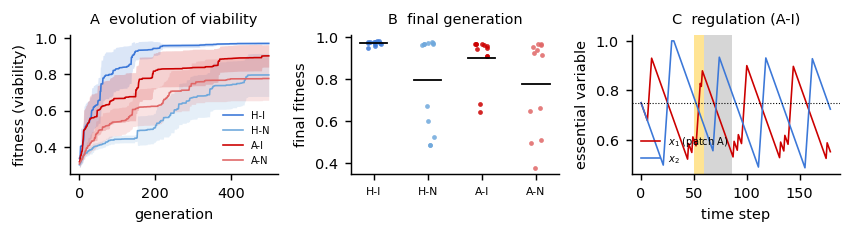

In [17]:
# ---- Figure 1: task and evolution -----------------------------------------
allh = {c: [] for c in CONDITIONS}
for r in records:
    allh[r["cond"]].append(r["history"][:, 1])

fig, ax = plt.subplots(1, 3, figsize=(6.6, 1.85))
for c in CONDITIONS:
    H = np.array(allh[c]); m, se = H.mean(0), H.std(0) / np.sqrt(len(H))
    g = np.arange(H.shape[1])
    ax[0].plot(g, m, color=CCOLOR[c], lw=.9, label=c)
    ax[0].fill_between(g, m - 1.96*se, m + 1.96*se, color=CCOLOR[c], alpha=.18, lw=0)
ax[0].set_xlabel("generation"); ax[0].set_ylabel("fitness (viability)")
ax[0].legend(fontsize=5.5, loc="lower right"); ax[0].set_title("A  evolution of viability")

for i, c in enumerate(CONDITIONS):
    y = df[df.cond == c]["fitness"].to_numpy()
    ax[1].scatter(np.full(len(y), i) + np.random.uniform(-.13, .13, len(y)), y,
                  s=7, color=CCOLOR[c], alpha=.85, lw=0)
    ax[1].plot([i-.25, i+.25], [y.mean()]*2, color="k", lw=1)
ax[1].set_xticks(range(4)); ax[1].set_xticklabels(CONDITIONS, fontsize=6)
ax[1].set_ylabel("final fitness"); ax[1].set_title("B  final generation")

EXC = "A-I" if (V.cond == "A-I").any() else V.cond.iloc[0]
ex = V[V.cond == EXC].sort_values("fitness", ascending=False).iloc[0]
rec = records[int(ex["idx"])]
tpm = condition_tpm(build_tpm(parse_genome(rec["genome"])), EXC)
_, lg = simulate_single(tpm, EXC)
tr = lg[lg.life == 0]
cu, wi = np.flatnonzero(tr["cue"].to_numpy()), np.flatnonzero(tr["winter"].to_numpy())
if len(cu): ax[2].axvspan(cu[0], cu[-1]+1, color="#FFD966", alpha=.7, lw=0)
if len(wi): ax[2].axvspan(wi[0], wi[-1]+1, color="#BBBBBB", alpha=.6, lw=0)
ax[2].plot(tr.t, tr.x1, color="#CC0000", lw=.9, label="$x_1$ (patch A)")
ax[2].plot(tr.t, tr.x2, color="#3C78D8", lw=.9, label="$x_2$")
ax[2].axhline(ENV.setpoint, color="k", ls=":", lw=.6)
ax[2].set_xlabel("time step"); ax[2].set_ylabel("essential variable")
ax[2].legend(fontsize=5.5, loc="lower left")
ax[2].set_title(f"C  regulation ({EXC})")
fig.tight_layout(); fig.savefig(OUTDIR / "fig1.pdf"); plt.show()

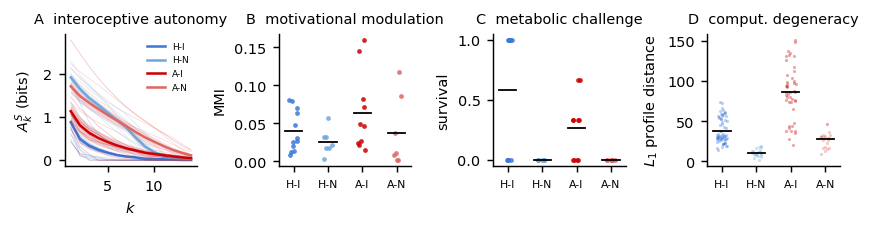

In [18]:
# ---- Figure 2: autonomy, motivation, ultrastability, degeneracy ------------
fig, ax = plt.subplots(1, 4, figsize=(6.6, 1.8))
kk = np.arange(1, 15)
for c in CONDITIONS:
    idxs_c = V[V.cond == c]["idx"].astype(int)
    if len(idxs_c) == 0:
        continue
    Ak = np.array([store[i]["ak"] for i in idxs_c])
    for row in Ak:
        ax[0].plot(kk, row, color=CCOLOR[c], lw=.4, alpha=.25)
    m, se = Ak.mean(0), Ak.std(0) / np.sqrt(len(Ak))
    ax[0].plot(kk, m, color=CCOLOR[c], lw=1.4, label=c)
    ax[0].fill_between(kk, m-se, m+se, color=CCOLOR[c], alpha=.2, lw=0)
ax[0].set_xlabel("$k$"); ax[0].set_ylabel("$A_k^S$ (bits)")
ax[0].legend(fontsize=5, loc="upper right"); ax[0].set_title("A  interoceptive autonomy")

def strip(a, col, ylab, title):
    for i, c in enumerate(CONDITIONS):
        y = V[V.cond == c][col].dropna().to_numpy()
        if not len(y): continue
        a.scatter(np.full(len(y), i) + np.random.uniform(-.13, .13, len(y)), y,
                  s=7, color=CCOLOR[c], alpha=.85, lw=0)
        a.plot([i-.25, i+.25], [y.mean()]*2, color="k", lw=1)
    a.set_xticks(range(4)); a.set_xticklabels(CONDITIONS, fontsize=6)
    a.set_ylabel(ylab); a.set_title(title)

strip(ax[1], "MMI", "MMI", "B  motivational modulation")
strip(ax[2], "met_survival", "survival", "C  metabolic challenge")
for i, c in enumerate(CONDITIONS):
    if c not in DEG: continue
    D, _ = DEG[c]; iu = np.triu_indices(D.shape[0], 1); y = D[iu]
    ax[3].scatter(np.full(len(y), i) + np.random.uniform(-.15, .15, len(y)), y,
                  s=3, color=CCOLOR[c], alpha=.35, lw=0)
    ax[3].plot([i-.25, i+.25], [y.mean()]*2, color="k", lw=1)
ax[3].set_xticks(range(4)); ax[3].set_xticklabels(CONDITIONS, fontsize=6)
ax[3].set_ylabel("$L_1$ profile distance"); ax[3].set_title("D  comput. degeneracy")
fig.tight_layout(); fig.savefig(OUTDIR / "fig2.pdf"); plt.show()

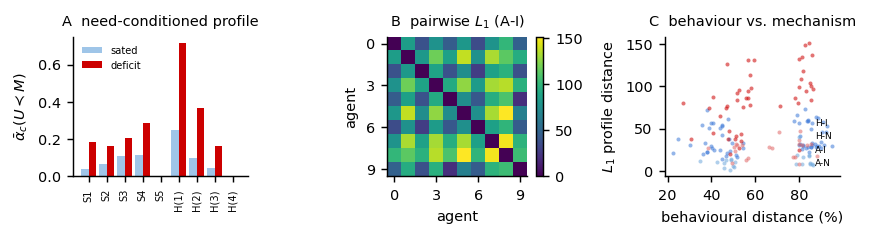

In [19]:
# ---- Figure 3: need-conditioned profile, degeneracy matrix, decoupling -----
fig, ax = plt.subplots(1, 3, figsize=(6.6, 1.85))
lbl = ["S1", "S2", "S3", "S4", "S5", "H(1)", "H(2)", "H(3)", "H(4)"]
PC = "A-I" if (V.cond == "A-I").any() else V.cond.iloc[0]
sel_ag = V[V.cond == PC].sort_values("MMI", ascending=False).iloc[0]
i0 = int(sel_ag["idx"])
keys = sorted(set(store[i0]["profile_deficit"]) | set(store[i0]["profile_sated"]))
a_def = profile_matrix(store[i0]["profile_deficit"], keys).mean(0)
a_sat = profile_matrix(store[i0]["profile_sated"], keys).mean(0)
x = np.arange(9)
ax[0].bar(x-.2, a_sat, .4, color="#9FC5E8", label="sated")
ax[0].bar(x+.2, a_def, .4, color="#CC0000", label="deficit")
ax[0].set_xticks(x); ax[0].set_xticklabels(lbl, fontsize=5.5, rotation=90)
ax[0].set_ylabel(r"$\bar\alpha_c(U\prec M)$"); ax[0].legend(fontsize=5.5)
ax[0].set_title("A  need-conditioned profile")

DM = "A-I" if "A-I" in DEG else list(DEG)[0]
D, _ = DEG[DM]
im = ax[1].imshow(D, cmap="viridis"); plt.colorbar(im, ax=ax[1], fraction=.046)
ax[1].set_xticks(range(0, D.shape[0], 3)); ax[1].set_yticks(range(0, D.shape[0], 3))
ax[1].set_title(f"B  pairwise $L_1$ ({DM})"); ax[1].set_xlabel("agent"); ax[1].set_ylabel("agent")

for c in CONDITIONS:
    m = lab == c
    ax[2].scatter(bb[m]*100, dd[m], s=5, color=CCOLOR[c], alpha=.55, lw=0, label=c)
ax[2].set_xlabel("behavioural distance (%)"); ax[2].set_ylabel("$L_1$ profile distance")
ax[2].set_title("C  behaviour vs. mechanism"); ax[2].legend(fontsize=5, loc="lower right")
fig.tight_layout(); fig.savefig(OUTDIR / "fig3.pdf"); plt.show()

---
## 12. Inspect a single agent

Useful for building intuition: pick any champion and look at its connectome,
its regulation trace and the causal account of one of its decisions.

agent 34  condition A-I  fitness 0.9684
structure: {'cS': 5, 'cH': 4, 'cM': 2, 'cN': 11, 'n_conn': 23, 's_h': 8, 's_m': 5, 'h_h': 6, 'h_m': 4, 'len_LSCC': 2}

causal account of the motor state in transition 222 -> 20 (deficit = 1):
  ['M1']  alpha_c = 0.093   actual cause(s): [['C']]
  ['M2']  alpha_c = 1.000   actual cause(s): [['D']]
  ['M1', 'M2']  alpha_c = 0.019   actual cause(s): [['B', 'C', 'S2', 'S4'], ['B', 'C', 'D', 'S2', 'S4']]
  alpha_c(B < M) = 0.250
  alpha_c(C < M) = 1.250
  alpha_c(D < M) = 1.000
  alpha_c(S2 < M) = 0.250
  alpha_c(S4 < M) = 0.250


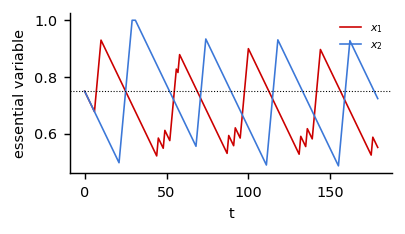

In [20]:
PICK = "A-I" if (V.cond == "A-I").any() else V.cond.iloc[0]
AGENT = int(V[V.cond == PICK].sort_values("fitness", ascending=False).iloc[0]["idx"])
rec = records[AGENT]
tpm = condition_tpm(build_tpm(parse_genome(rec["genome"])), rec["cond"])
cm = effective_cm(tpm)
f, log = simulate_single(tpm, rec["cond"])
print(f"agent {AGENT}  condition {rec['cond']}  fitness {f:.4f}")
print("structure:", structural_analysis(cm))

trans = causal_transitions(log)
ac = ActualCausation(tpm)
row = trans.iloc[int(np.argmax(trans.deficit.to_numpy()))]
c_state, e_state = int(row.c_state), int(row.e_state)
print(f"\ncausal account of the motor state in transition "
      f"{c_state} -> {e_state} (deficit = {row.deficit}):")
for mech, alpha, ties, _ in ac.cause_account(c_state, e_state):
    names = [[NODE_LABELS[MOTOR_IXS[m - N_HIDDEN]] for m in mech]]
    purv = [[NODE_LABELS[CAUSE_IXS[p]] for p in t] for t in ties]
    print(f"  {names[0]}  alpha_c = {alpha:.3f}   actual cause(s): {purv}")

contrib = ac.unit_contributions(c_state, e_state)
for i, v in enumerate(contrib):
    if v > 1e-6:
        print(f"  alpha_c({NODE_LABELS[CAUSE_IXS[i]]} < M) = {v:.3f}")

fig, ax = plt.subplots(figsize=(3.2, 1.6))
tr = log[log.life == 0]
ax.plot(tr.t, tr.x1, color="#CC0000", lw=.9, label="$x_1$")
ax.plot(tr.t, tr.x2, color="#3C78D8", lw=.9, label="$x_2$")
ax.axhline(ENV.setpoint, ls=":", color="k", lw=.6)
ax.set_xlabel("t"); ax.set_ylabel("essential variable"); ax.legend(fontsize=6)
plt.show()

---
### References

* Albantakis, L. (2021). Quantifying the autonomy of structurally diverse
  automata: a comparison of candidate measures. *Entropy* 23(11), 1415.
* Albantakis, L., Marshall, W., Hoel, E., Tononi, G. (2019). What caused what?
  A quantitative account of actual causation using dynamical causal networks.
  *Entropy* 21(5), 459.
* Ashby, W. R. (1952). *Design for a Brain*. Chapman & Hall.
* Bertschinger, N., Olbrich, E., Ay, N., Jost, J. (2008). Autonomy: an
  information theoretic perspective. *Biosystems* 91(2), 331-345.
* Canamero, L. (1997). Modeling motivations and emotions as a basis for
  intelligent behavior. In *Agents '97*, 148-155.
* Hintze, A. et al. (2017). Markov brains: a technical introduction.
  arXiv:1709.05601.
* Hu, Z., Cingiler, O., Bohm, C., Albantakis, L. (2025). From function to
  implementation: exploring degeneracy in evolved artificial agents.
  *Neural Computation* 37(9), 1677-1708.
* Keramati, M., Gutkin, B. (2014). Homeostatic reinforcement learning for
  integrating reward collection and physiological stability. *eLife* 3, e04811.
* Sterling, P. (2012). Allostasis: a model of predictive regulation.
  *Physiology & Behavior* 106(1), 5-15.
* Tononi, G., Sporns, O., Edelman, G. M. (1999). Measures of degeneracy and
  redundancy in biological networks. *PNAS* 96(6), 3257-3262.
